# Notebook 2: APS XYZ + Normals Baseline Experiments

This notebook performs the original PointNet++ baseline experiments using XYZ coordinates together with surface normals.

Three APS training conditions are evaluated:

1. APS-clean
2. APS-error
3. Mixed APS-clean + APS-error

Each trained model is evaluated on:

1. APS-clean test set
2. APS-error test set
3. APS-error-double test set

The final experiment uses 1000 points per sample and nine independent training runs for each training condition.

This notebook represents the original XYZ + normals baseline. The later XYZ-only experiments are evaluated separately and form the final configuration used for external YCB-28 testing.

In [ ]:
# Mount drive, imports and paths
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

# Project paths
PROJECT_DIR = Path("/content/drive/MyDrive/PointNet_APS_Project_V2")
SRC_DIR = PROJECT_DIR / "src"
METADATA_DIR = PROJECT_DIR / "metadata"
MODELS_DIR = PROJECT_DIR / "models_final"
RESULTS_DIR = PROJECT_DIR / "results_final"
FIGURES_DIR = PROJECT_DIR / "figures_final"

# Add utility file path
sys.path.append(str(SRC_DIR))

from pointnetpp_aps_utils import (
    APSPointCloudDataset,
    PointNetPPClassifier,
    set_global_seed,
    LABEL_NAME
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Project folder:", PROJECT_DIR)

Mounted at /content/drive
Using device: cuda
GPU: Tesla T4
Project folder: /content/drive/MyDrive/PointNet_APS_Project_V2


In [ ]:
# Load dataset manifest from NB1
manifest_path = METADATA_DIR / "dataset_manifest_v2.csv"

manifest_df = pd.read_csv(manifest_path)

print("Manifest loaded from:")
print(manifest_path)

print("\nAvailable roles:")
print(manifest_df["role"].value_counts())

print("\nAvailable variants:")
print(manifest_df["variant"].value_counts())

Manifest loaded from:
/content/drive/MyDrive/PointNet_APS_Project_V2/metadata/dataset_manifest_v2.csv

Available roles:
role
test_error                 600
test_clean                 600
validation                 600
test_error_double          600
optional_reference_only    591
train_clean_condition      591
train_error_condition      591
Name: count, dtype: int64

Available variants:
variant
aps_error_test_style           600
aps_clean_test_style           600
aps_clean_val_style            600
aps_error_double_test_style    600
aps_error_double_raw           591
aps_clean_raw                  591
aps_error_raw                  591
Name: count, dtype: int64


In [ ]:
# Create train, validation and test dataframe
train_clean_df = manifest_df[manifest_df["role"] == "train_clean_condition"].reset_index(drop=True)
train_error_df = manifest_df[manifest_df["role"] == "train_error_condition"].reset_index(drop=True)

# Mixed training = clean + error
train_mixed_df = pd.concat([train_clean_df, train_error_df], ignore_index=True)

val_df = manifest_df[manifest_df["role"] == "validation"].reset_index(drop=True)

test_clean_df = manifest_df[manifest_df["role"] == "test_clean"].reset_index(drop=True)
test_error_df = manifest_df[manifest_df["role"] == "test_error"].reset_index(drop=True)
test_error_double_df = manifest_df[manifest_df["role"] == "test_error_double"].reset_index(drop=True)

print("Train clean:", len(train_clean_df))
print("Train error:", len(train_error_df))
print("Train mixed:", len(train_mixed_df))
print("Validation:", len(val_df))
print("Test clean:", len(test_clean_df))
print("Test error:", len(test_error_df))
print("Test error_double:", len(test_error_double_df))

print("\nValidation class counts:")
print(val_df["class_name"].value_counts())

Train clean: 591
Train error: 591
Train mixed: 1182
Validation: 600
Test clean: 600
Test error: 600
Test error_double: 600

Validation class counts:
class_name
box         200
cylinder    200
sphere      200
Name: count, dtype: int64


In [ ]:
# Experiment/test setup

N_POINTS = 1000
USE_NORMALS = True
BATCH_SIZE = 16

# Short sanity-check configuration
SANITY_EPOCHS = 3

# Final baseline experiment configuration
FULL_EPOCHS = 25
NUM_RUNS = 9

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

CLASS_NAMES = ["box", "cylinder", "sphere"]

print("Settings ready.")
print("N_POINTS:", N_POINTS)
print("USE_NORMALS:", USE_NORMALS)
print("BATCH_SIZE:", BATCH_SIZE)
print("Sanity epochs:", SANITY_EPOCHS)
print("Full epochs:", FULL_EPOCHS)
print("Number of repeated runs:", NUM_RUNS)

Settings ready.
N_POINTS: 1000
USE_NORMALS: True
BATCH_SIZE: 16
Sanity epochs: 3
Full epochs: 25
Number of repeated runs: 5


In [ ]:
# DATALOADER Function
def make_loader(df, batch_size=BATCH_SIZE, shuffle=False):
    dataset = APSPointCloudDataset(
        df,
        n_points=N_POINTS,
        use_normals=USE_NORMALS,
        normalise=True
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return loader


# Test dataloaders
train_clean_loader = make_loader(train_clean_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)
test_clean_loader = make_loader(test_clean_df, shuffle=False)

points, labels = next(iter(train_clean_loader))

print("Batch points shape:", points.shape)
print("Batch labels shape:", labels.shape)

Batch points shape: torch.Size([16, 6, 1000])
Batch labels shape: torch.Size([16])


In [ ]:
# Evaluation
def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_true = []
    all_pred = []
    all_conf = []

    with torch.no_grad():
        for points, labels in loader:
            points = points.to(device)
            labels = labels.to(device)

            logits = model(points)
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)
            conf, preds = torch.max(probs, dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_conf.extend(conf.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "true": np.array(all_true),
        "pred": np.array(all_pred),
        "confidence": np.array(all_conf)
    }

In [ ]:
# Training
def train_one_model(
    train_df,
    val_df,
    train_condition_name,
    run_id,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=42
):
    set_global_seed(seed)

    train_loader = make_loader(train_df, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(val_df, batch_size=batch_size, shuffle=False)

    model = PointNetPPClassifier(
        num_classes=3,
        normal_channel=USE_NORMALS
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=15,
        gamma=0.5
    )

    model_dir = MODELS_DIR / train_condition_name
    model_dir.mkdir(parents=True, exist_ok=True)

    best_model_path = model_dir / f"{train_condition_name}_run_{run_id}_best.pth"

    history = []
    best_val_acc = 0.0
    best_epoch = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for points, labels in train_loader:
            points = points.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(points)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        scheduler.step()

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        val_result = evaluate_model(model, val_loader, criterion, device)
        val_loss = val_result["loss"]
        val_acc = val_result["accuracy"]

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch

            torch.save({
                "model_state_dict": model.state_dict(),
                "train_condition": train_condition_name,
                "run_id": run_id,
                "epoch": epoch,
                "val_accuracy": val_acc,
                "val_loss": val_loss,
                "settings": {
                    "n_points": N_POINTS,
                    "use_normals": USE_NORMALS,
                    "batch_size": batch_size,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": seed
                }
            }, best_model_path)

        history.append({
            "train_condition": train_condition_name,
            "run_id": run_id,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "best_val_accuracy_so_far": best_val_acc
        })

        print(
            f"[{train_condition_name} | Run {run_id}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    end_time = time.time()

    history_df = pd.DataFrame(history)

    history_path = RESULTS_DIR / "run_logs" / f"{train_condition_name}_run_{run_id}_history.csv"
    history_df.to_csv(history_path, index=False)

    print("\nTraining complete.")
    print("Best validation accuracy:", best_val_acc)
    print("Best epoch:", best_epoch)
    print("Saved best model:", best_model_path)
    print("Saved history:", history_path)
    print("Training time minutes:", round((end_time - start_time) / 60, 2))

    return best_model_path, history_df

In [ ]:
# Test model on test sets
def evaluate_saved_model_on_tests(
    model_path,
    train_condition_name,
    run_id,
    test_sets_dict
):
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(model_path, map_location=device)

    model = PointNetPPClassifier(
        num_classes=3,
        normal_channel=USE_NORMALS
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    summary_records = []

    for test_name, test_df in test_sets_dict.items():
        test_loader = make_loader(test_df, batch_size=BATCH_SIZE, shuffle=False)

        result = evaluate_model(model, test_loader, criterion, device)

        acc = result["accuracy"]
        loss = result["loss"]

        y_true = result["true"]
        y_pred = result["pred"]
        confidence = result["confidence"]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

        # Save confusion matrix
        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASS_NAMES],
            columns=[f"pred_{c}" for c in CLASS_NAMES]
        )

        cm_path = RESULTS_DIR / "confusion_matrices" / f"{train_condition_name}_run_{run_id}_{test_name}_cm.csv"
        cm_df.to_csv(cm_path)

        # Save prediction records
        pred_records = pd.DataFrame({
            "train_condition": train_condition_name,
            "run_id": run_id,
            "test_set": test_name,
            "true_label": y_true,
            "pred_label": y_pred,
            "true_class": [CLASS_NAMES[i] for i in y_true],
            "pred_class": [CLASS_NAMES[i] for i in y_pred],
            "confidence": confidence,
            "correct": y_true == y_pred
        })

        pred_path = RESULTS_DIR / "test_results" / f"{train_condition_name}_run_{run_id}_{test_name}_predictions.csv"
        pred_records.to_csv(pred_path, index=False)

        summary_records.append({
            "train_condition": train_condition_name,
            "run_id": run_id,
            "test_set": test_name,
            "test_loss": loss,
            "test_accuracy": acc,
            "correct_predictions": int((y_true == y_pred).sum()),
            "wrong_predictions": int((y_true != y_pred).sum()),
            "total_samples": int(len(y_true)),
            "model_path": str(model_path),
            "confusion_matrix_path": str(cm_path),
            "prediction_records_path": str(pred_path)
        })

        print(
            f"{train_condition_name} | Run {run_id} | {test_name} | "
            f"Loss: {loss:.4f} | Accuracy: {acc:.4f}"
        )

    summary_df = pd.DataFrame(summary_records)

    summary_path = RESULTS_DIR / "test_results" / f"{train_condition_name}_run_{run_id}_test_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    print("\nSaved test summary:")
    print(summary_path)

    return summary_df

In [ ]:
# Define test sets
test_sets_dict = {
    "aps_clean_test": test_clean_df,
    "aps_error_test": test_error_df,
    "aps_error_double_test": test_error_double_df
}

print("Test sets ready:")
for name, df in test_sets_dict.items():
    print(name, len(df))

Test sets ready:
aps_clean_test 600
aps_error_test 600
aps_error_double_test 600


In [ ]:
# Full experiment check 1: Clean-trained model, Run 1

clean_model_path_run1, clean_history_run1 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=1,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=201
)

clean_summary_run1 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run1,
    train_condition_name="clean_trained",
    run_id=1,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run1)

[clean_trained | Run 1] Epoch 01/25 | Train Loss: 0.5038 | Train Acc: 0.7783 | Val Loss: 1.1912 | Val Acc: 0.4000
[clean_trained | Run 1] Epoch 02/25 | Train Loss: 0.2722 | Train Acc: 0.9171 | Val Loss: 0.4221 | Val Acc: 0.8250
[clean_trained | Run 1] Epoch 03/25 | Train Loss: 0.2095 | Train Acc: 0.9323 | Val Loss: 0.0466 | Val Acc: 0.9950
[clean_trained | Run 1] Epoch 04/25 | Train Loss: 0.1243 | Train Acc: 0.9679 | Val Loss: 0.0372 | Val Acc: 0.9917
[clean_trained | Run 1] Epoch 05/25 | Train Loss: 0.2270 | Train Acc: 0.9188 | Val Loss: 0.2334 | Val Acc: 0.9083
[clean_trained | Run 1] Epoch 06/25 | Train Loss: 0.1849 | Train Acc: 0.9272 | Val Loss: 0.0637 | Val Acc: 0.9850
[clean_trained | Run 1] Epoch 07/25 | Train Loss: 0.1548 | Train Acc: 0.9459 | Val Loss: 0.0819 | Val Acc: 0.9700
[clean_trained | Run 1] Epoch 08/25 | Train Loss: 0.1126 | Train Acc: 0.9662 | Val Loss: 0.0345 | Val Acc: 0.9883
[clean_trained | Run 1] Epoch 09/25 | Train Loss: 0.0956 | Train Acc: 0.9712 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,1,aps_clean_test,0.021585,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,1,aps_error_test,0.022782,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,1,aps_error_double_test,0.029310,0.993333,596,4,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment 2: Error-trained model, Run 1

error_model_path_run1, error_history_run1 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=1,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=301
)

error_summary_run1 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run1,
    train_condition_name="error_trained",
    run_id=1,
    test_sets_dict=test_sets_dict
)

display(error_summary_run1)

[error_trained | Run 1] Epoch 01/25 | Train Loss: 0.5235 | Train Acc: 0.7817 | Val Loss: 0.8463 | Val Acc: 0.6667
[error_trained | Run 1] Epoch 02/25 | Train Loss: 0.2860 | Train Acc: 0.8849 | Val Loss: 0.0906 | Val Acc: 0.9767
[error_trained | Run 1] Epoch 03/25 | Train Loss: 0.2229 | Train Acc: 0.9222 | Val Loss: 0.1621 | Val Acc: 0.9283
[error_trained | Run 1] Epoch 04/25 | Train Loss: 0.2541 | Train Acc: 0.9171 | Val Loss: 0.0635 | Val Acc: 0.9833
[error_trained | Run 1] Epoch 05/25 | Train Loss: 0.1413 | Train Acc: 0.9611 | Val Loss: 0.0174 | Val Acc: 1.0000
[error_trained | Run 1] Epoch 06/25 | Train Loss: 0.2138 | Train Acc: 0.9103 | Val Loss: 0.1631 | Val Acc: 0.9383
[error_trained | Run 1] Epoch 07/25 | Train Loss: 0.2131 | Train Acc: 0.9222 | Val Loss: 0.0486 | Val Acc: 0.9950
[error_trained | Run 1] Epoch 08/25 | Train Loss: 0.1396 | Train Acc: 0.9645 | Val Loss: 0.0169 | Val Acc: 0.9983
[error_trained | Run 1] Epoch 09/25 | Train Loss: 0.1719 | Train Acc: 0.9374 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,1,aps_clean_test,0.016996,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,1,aps_error_test,0.018467,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,1,aps_error_double_test,0.022032,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check 3: Mixed-trained model, Run 1

mixed_model_path_run1, mixed_history_run1 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=1,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=401
)

mixed_summary_run1 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run1,
    train_condition_name="mixed_trained",
    run_id=1,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run1)

[mixed_trained | Run 1] Epoch 01/25 | Train Loss: 0.3773 | Train Acc: 0.8384 | Val Loss: 0.3482 | Val Acc: 0.8200
[mixed_trained | Run 1] Epoch 02/25 | Train Loss: 0.1908 | Train Acc: 0.9298 | Val Loss: 0.1854 | Val Acc: 0.9317
[mixed_trained | Run 1] Epoch 03/25 | Train Loss: 0.1418 | Train Acc: 0.9509 | Val Loss: 0.0395 | Val Acc: 0.9917
[mixed_trained | Run 1] Epoch 04/25 | Train Loss: 0.1146 | Train Acc: 0.9619 | Val Loss: 0.0462 | Val Acc: 0.9933
[mixed_trained | Run 1] Epoch 05/25 | Train Loss: 0.0998 | Train Acc: 0.9662 | Val Loss: 0.0366 | Val Acc: 0.9867
[mixed_trained | Run 1] Epoch 06/25 | Train Loss: 0.0940 | Train Acc: 0.9662 | Val Loss: 0.0116 | Val Acc: 1.0000
[mixed_trained | Run 1] Epoch 07/25 | Train Loss: 0.0916 | Train Acc: 0.9687 | Val Loss: 0.0079 | Val Acc: 1.0000
[mixed_trained | Run 1] Epoch 08/25 | Train Loss: 0.1206 | Train Acc: 0.9577 | Val Loss: 0.0604 | Val Acc: 0.9883
[mixed_trained | Run 1] Epoch 09/25 | Train Loss: 0.0598 | Train Acc: 0.9814 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,1,aps_clean_test,0.015884,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,1,aps_error_test,0.015941,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,1,aps_error_double_test,0.023367,0.995000,597,3,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Combine Run 1 summaries from clean, error and mixed trained models

run1_combined_summary = pd.concat(
    [
        clean_summary_run1,
        error_summary_run1,
        mixed_summary_run1
    ],
    ignore_index=True
)

run1_combined_path = RESULTS_DIR / "test_results" / "run1_all_training_conditions_summary.csv"
run1_combined_summary.to_csv(run1_combined_path, index=False)

print("Saved Run 1 combined summary to:")
print(run1_combined_path)

display(
    run1_combined_summary[
        [
            "train_condition",
            "run_id",
            "test_set",
            "test_accuracy",
            "correct_predictions",
            "wrong_predictions",
            "total_samples"
        ]
    ]
)

Saved Run 1 combined summary to:
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final/test_results/run1_all_training_conditions_summary.csv


,train_condition,run_id,test_set,test_accuracy,correct_predictions,wrong_predictions,total_samples
0,clean_trained,1,aps_clean_test,0.996667,598,2,600
1,clean_trained,1,aps_error_test,0.996667,598,2,600
2,clean_trained,1,aps_error_double_test,0.993333,596,4,600
3,error_trained,1,aps_clean_test,1.000000,600,0,600
4,error_trained,1,aps_error_test,1.000000,600,0,600
5,error_trained,1,aps_error_double_test,1.000000,600,0,600
6,mixed_trained,1,aps_clean_test,0.996667,598,2,600
7,mixed_trained,1,aps_error_test,0.998333,599,1,600
8,mixed_trained,1,aps_error_double_test,0.995000,597,3,600


In [ ]:
def run_single_experiment(train_condition_name, train_df_current, run_id, seed):
    print("=" * 80)
    print(f"Starting: {train_condition_name} | Run {run_id}")
    print("=" * 80)

    summary_path = RESULTS_DIR / "test_results" / f"{train_condition_name}_run_{run_id}_test_summary.csv"
    model_path = MODELS_DIR / train_condition_name / f"{train_condition_name}_run_{run_id}_best.pth"

    # If already completed, load result
    if summary_path.exists():
        print("This experiment is already completed. Loading saved summary:")
        print(summary_path)
        summary_df = pd.read_csv(summary_path)
        display(summary_df)
        return summary_df

    # If model exists but summary missing, only evaluate
    if model_path.exists():
        print("Model exists but summary missing. Evaluating saved model:")
        print(model_path)

        summary_df = evaluate_saved_model_on_tests(
            model_path=model_path,
            train_condition_name=train_condition_name,
            run_id=run_id,
            test_sets_dict=test_sets_dict
        )

        display(summary_df)
        return summary_df

    # Otherwise train and evaluate
    trained_model_path, history_df = train_one_model(
        train_df=train_df_current,
        val_df=val_df,
        train_condition_name=train_condition_name,
        run_id=run_id,
        epochs=FULL_EPOCHS,
        batch_size=BATCH_SIZE,
        seed=seed
    )

    summary_df = evaluate_saved_model_on_tests(
        model_path=trained_model_path,
        train_condition_name=train_condition_name,
        run_id=run_id,
        test_sets_dict=test_sets_dict
    )

    display(summary_df)

    print(f"Completed: {train_condition_name} | Run {run_id}")
    return summary_df

In [ ]:
# Full experiment check: Clean-trained model, Run 2

clean_model_path_run2, clean_history_run2 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=2,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=202
)

clean_summary_run2 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run2,
    train_condition_name="clean_trained",
    run_id=2,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run2)

[clean_trained | Run 2] Epoch 01/25 | Train Loss: 0.5036 | Train Acc: 0.7766 | Val Loss: 1.1338 | Val Acc: 0.3983
[clean_trained | Run 2] Epoch 02/25 | Train Loss: 0.2141 | Train Acc: 0.9222 | Val Loss: 0.3998 | Val Acc: 0.8483
[clean_trained | Run 2] Epoch 03/25 | Train Loss: 0.1815 | Train Acc: 0.9459 | Val Loss: 0.2518 | Val Acc: 0.8783
[clean_trained | Run 2] Epoch 04/25 | Train Loss: 0.1895 | Train Acc: 0.9239 | Val Loss: 0.0498 | Val Acc: 0.9900
[clean_trained | Run 2] Epoch 05/25 | Train Loss: 0.1373 | Train Acc: 0.9628 | Val Loss: 0.0162 | Val Acc: 1.0000
[clean_trained | Run 2] Epoch 06/25 | Train Loss: 0.2186 | Train Acc: 0.9357 | Val Loss: 0.1632 | Val Acc: 0.9267
[clean_trained | Run 2] Epoch 07/25 | Train Loss: 0.1272 | Train Acc: 0.9712 | Val Loss: 0.0237 | Val Acc: 1.0000
[clean_trained | Run 2] Epoch 08/25 | Train Loss: 0.0880 | Train Acc: 0.9780 | Val Loss: 0.0120 | Val Acc: 1.0000
[clean_trained | Run 2] Epoch 09/25 | Train Loss: 0.0967 | Train Acc: 0.9679 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,2,aps_clean_test,0.017948,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,2,aps_error_test,0.019872,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,2,aps_error_double_test,0.021134,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 2

error_model_path_run2, error_history_run2 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=2,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=302
)

error_summary_run2 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run2,
    train_condition_name="error_trained",
    run_id=2,
    test_sets_dict=test_sets_dict
)

display(error_summary_run2)

[error_trained | Run 2] Epoch 01/25 | Train Loss: 0.4992 | Train Acc: 0.7648 | Val Loss: 0.9828 | Val Acc: 0.3433
[error_trained | Run 2] Epoch 02/25 | Train Loss: 0.1967 | Train Acc: 0.9306 | Val Loss: 0.0839 | Val Acc: 0.9717
[error_trained | Run 2] Epoch 03/25 | Train Loss: 0.2133 | Train Acc: 0.9036 | Val Loss: 0.1141 | Val Acc: 0.9617
[error_trained | Run 2] Epoch 04/25 | Train Loss: 0.1432 | Train Acc: 0.9509 | Val Loss: 0.0844 | Val Acc: 0.9800
[error_trained | Run 2] Epoch 05/25 | Train Loss: 0.1357 | Train Acc: 0.9526 | Val Loss: 0.4298 | Val Acc: 0.8200
[error_trained | Run 2] Epoch 06/25 | Train Loss: 0.1410 | Train Acc: 0.9492 | Val Loss: 0.0354 | Val Acc: 0.9983
[error_trained | Run 2] Epoch 07/25 | Train Loss: 0.1946 | Train Acc: 0.9459 | Val Loss: 0.1623 | Val Acc: 0.9250
[error_trained | Run 2] Epoch 08/25 | Train Loss: 0.0954 | Train Acc: 0.9662 | Val Loss: 0.0190 | Val Acc: 1.0000
[error_trained | Run 2] Epoch 09/25 | Train Loss: 0.0831 | Train Acc: 0.9780 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,2,aps_clean_test,0.018456,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,2,aps_error_test,0.017963,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,2,aps_error_double_test,0.017727,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 2

mixed_model_path_run2, mixed_history_run2 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=2,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=402
)

mixed_summary_run2 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run2,
    train_condition_name="mixed_trained",
    run_id=2,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run2)

[mixed_trained | Run 2] Epoch 01/25 | Train Loss: 0.3949 | Train Acc: 0.8460 | Val Loss: 0.3589 | Val Acc: 0.8367
[mixed_trained | Run 2] Epoch 02/25 | Train Loss: 0.1919 | Train Acc: 0.9281 | Val Loss: 0.0564 | Val Acc: 0.9850
[mixed_trained | Run 2] Epoch 03/25 | Train Loss: 0.1540 | Train Acc: 0.9442 | Val Loss: 0.1249 | Val Acc: 0.9467
[mixed_trained | Run 2] Epoch 04/25 | Train Loss: 0.1398 | Train Acc: 0.9467 | Val Loss: 0.2197 | Val Acc: 0.9067
[mixed_trained | Run 2] Epoch 05/25 | Train Loss: 0.1180 | Train Acc: 0.9509 | Val Loss: 0.0196 | Val Acc: 0.9983
[mixed_trained | Run 2] Epoch 06/25 | Train Loss: 0.1227 | Train Acc: 0.9611 | Val Loss: 0.0623 | Val Acc: 0.9933
[mixed_trained | Run 2] Epoch 07/25 | Train Loss: 0.0646 | Train Acc: 0.9797 | Val Loss: 0.0174 | Val Acc: 0.9983
[mixed_trained | Run 2] Epoch 08/25 | Train Loss: 0.0659 | Train Acc: 0.9788 | Val Loss: 0.0114 | Val Acc: 1.0000
[mixed_trained | Run 2] Epoch 09/25 | Train Loss: 0.0802 | Train Acc: 0.9704 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,2,aps_clean_test,0.008539,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,2,aps_error_test,0.010434,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,2,aps_error_double_test,0.012334,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Clean-trained model, Run 3

clean_model_path_run3, clean_history_run3 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=3,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=203
)

clean_summary_run3 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run3,
    train_condition_name="clean_trained",
    run_id=3,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run3)

[clean_trained | Run 3] Epoch 01/25 | Train Loss: 0.5078 | Train Acc: 0.7597 | Val Loss: 0.9362 | Val Acc: 0.5683
[clean_trained | Run 3] Epoch 02/25 | Train Loss: 0.1991 | Train Acc: 0.9357 | Val Loss: 0.1013 | Val Acc: 0.9700
[clean_trained | Run 3] Epoch 03/25 | Train Loss: 0.1888 | Train Acc: 0.9374 | Val Loss: 0.0947 | Val Acc: 0.9667
[clean_trained | Run 3] Epoch 04/25 | Train Loss: 0.1655 | Train Acc: 0.9425 | Val Loss: 0.0455 | Val Acc: 0.9933
[clean_trained | Run 3] Epoch 05/25 | Train Loss: 0.2163 | Train Acc: 0.9357 | Val Loss: 0.3214 | Val Acc: 0.8700
[clean_trained | Run 3] Epoch 06/25 | Train Loss: 0.1523 | Train Acc: 0.9459 | Val Loss: 0.0267 | Val Acc: 0.9950
[clean_trained | Run 3] Epoch 07/25 | Train Loss: 0.1338 | Train Acc: 0.9543 | Val Loss: 0.0248 | Val Acc: 0.9967
[clean_trained | Run 3] Epoch 08/25 | Train Loss: 0.1444 | Train Acc: 0.9594 | Val Loss: 0.0193 | Val Acc: 0.9967
[clean_trained | Run 3] Epoch 09/25 | Train Loss: 0.1431 | Train Acc: 0.9475 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,3,aps_clean_test,0.020620,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,3,aps_error_test,0.022095,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,3,aps_error_double_test,0.022029,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 3

error_model_path_run3, error_history_run3 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=3,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=303
)

error_summary_run3 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run3,
    train_condition_name="error_trained",
    run_id=3,
    test_sets_dict=test_sets_dict
)

display(error_summary_run3)

[error_trained | Run 3] Epoch 01/25 | Train Loss: 0.4742 | Train Acc: 0.7953 | Val Loss: 0.8126 | Val Acc: 0.4033
[error_trained | Run 3] Epoch 02/25 | Train Loss: 0.2801 | Train Acc: 0.9052 | Val Loss: 0.0704 | Val Acc: 0.9800
[error_trained | Run 3] Epoch 03/25 | Train Loss: 0.1632 | Train Acc: 0.9374 | Val Loss: 0.0521 | Val Acc: 0.9883
[error_trained | Run 3] Epoch 04/25 | Train Loss: 0.1916 | Train Acc: 0.9272 | Val Loss: 0.0667 | Val Acc: 0.9783
[error_trained | Run 3] Epoch 05/25 | Train Loss: 0.2166 | Train Acc: 0.9154 | Val Loss: 1.3009 | Val Acc: 0.5500
[error_trained | Run 3] Epoch 06/25 | Train Loss: 0.1481 | Train Acc: 0.9475 | Val Loss: 0.0289 | Val Acc: 0.9983
[error_trained | Run 3] Epoch 07/25 | Train Loss: 0.2325 | Train Acc: 0.9306 | Val Loss: 0.0708 | Val Acc: 0.9783
[error_trained | Run 3] Epoch 08/25 | Train Loss: 0.1879 | Train Acc: 0.9374 | Val Loss: 0.0573 | Val Acc: 0.9867
[error_trained | Run 3] Epoch 09/25 | Train Loss: 0.1454 | Train Acc: 0.9475 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,3,aps_clean_test,0.011549,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,3,aps_error_test,0.011777,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,3,aps_error_double_test,0.012078,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 3

mixed_model_path_run3, mixed_history_run3 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=3,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=403
)

mixed_summary_run3 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run3,
    train_condition_name="mixed_trained",
    run_id=3,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run3)

[mixed_trained | Run 3] Epoch 01/25 | Train Loss: 0.3666 | Train Acc: 0.8553 | Val Loss: 0.1101 | Val Acc: 0.9450
[mixed_trained | Run 3] Epoch 02/25 | Train Loss: 0.1209 | Train Acc: 0.9585 | Val Loss: 0.0264 | Val Acc: 0.9983
[mixed_trained | Run 3] Epoch 03/25 | Train Loss: 0.1234 | Train Acc: 0.9577 | Val Loss: 0.0260 | Val Acc: 0.9967
[mixed_trained | Run 3] Epoch 04/25 | Train Loss: 0.1406 | Train Acc: 0.9442 | Val Loss: 0.0238 | Val Acc: 0.9967
[mixed_trained | Run 3] Epoch 05/25 | Train Loss: 0.1617 | Train Acc: 0.9577 | Val Loss: 0.0795 | Val Acc: 0.9767
[mixed_trained | Run 3] Epoch 06/25 | Train Loss: 0.1567 | Train Acc: 0.9569 | Val Loss: 0.0389 | Val Acc: 0.9950
[mixed_trained | Run 3] Epoch 07/25 | Train Loss: 0.1001 | Train Acc: 0.9645 | Val Loss: 0.0624 | Val Acc: 0.9800
[mixed_trained | Run 3] Epoch 08/25 | Train Loss: 0.0958 | Train Acc: 0.9662 | Val Loss: 0.3739 | Val Acc: 0.8617
[mixed_trained | Run 3] Epoch 09/25 | Train Loss: 0.0532 | Train Acc: 0.9839 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,3,aps_clean_test,0.004574,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,3,aps_error_test,0.005259,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,3,aps_error_double_test,0.005735,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Clean-trained model, Run 4

clean_model_path_run4, clean_history_run4 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=4,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=204
)

clean_summary_run4 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run4,
    train_condition_name="clean_trained",
    run_id=4,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run4)


[clean_trained | Run 4] Epoch 01/25 | Train Loss: 0.5289 | Train Acc: 0.7885 | Val Loss: 1.2681 | Val Acc: 0.3333
[clean_trained | Run 4] Epoch 02/25 | Train Loss: 0.2446 | Train Acc: 0.9205 | Val Loss: 0.0669 | Val Acc: 0.9783
[clean_trained | Run 4] Epoch 03/25 | Train Loss: 0.1624 | Train Acc: 0.9391 | Val Loss: 0.0296 | Val Acc: 0.9967
[clean_trained | Run 4] Epoch 04/25 | Train Loss: 0.1373 | Train Acc: 0.9662 | Val Loss: 0.0482 | Val Acc: 0.9883
[clean_trained | Run 4] Epoch 05/25 | Train Loss: 0.2088 | Train Acc: 0.9340 | Val Loss: 0.1743 | Val Acc: 0.9133
[clean_trained | Run 4] Epoch 06/25 | Train Loss: 0.1240 | Train Acc: 0.9509 | Val Loss: 0.0216 | Val Acc: 0.9950
[clean_trained | Run 4] Epoch 07/25 | Train Loss: 0.1274 | Train Acc: 0.9543 | Val Loss: 0.1368 | Val Acc: 0.9500
[clean_trained | Run 4] Epoch 08/25 | Train Loss: 0.1110 | Train Acc: 0.9611 | Val Loss: 0.0243 | Val Acc: 0.9967
[clean_trained | Run 4] Epoch 09/25 | Train Loss: 0.1173 | Train Acc: 0.9679 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,4,aps_clean_test,0.014598,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,4,aps_error_test,0.015899,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,4,aps_error_double_test,0.016815,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 4

error_model_path_run4, error_history_run4 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=4,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=304
)

error_summary_run4 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run4,
    train_condition_name="error_trained",
    run_id=4,
    test_sets_dict=test_sets_dict
)

display(error_summary_run4)


[error_trained | Run 4] Epoch 01/25 | Train Loss: 0.4694 | Train Acc: 0.7885 | Val Loss: 0.6112 | Val Acc: 0.8483
[error_trained | Run 4] Epoch 02/25 | Train Loss: 0.3235 | Train Acc: 0.8832 | Val Loss: 0.2392 | Val Acc: 0.9083
[error_trained | Run 4] Epoch 03/25 | Train Loss: 0.2250 | Train Acc: 0.9306 | Val Loss: 0.0547 | Val Acc: 0.9900
[error_trained | Run 4] Epoch 04/25 | Train Loss: 0.1564 | Train Acc: 0.9357 | Val Loss: 0.1908 | Val Acc: 0.9017
[error_trained | Run 4] Epoch 05/25 | Train Loss: 0.0834 | Train Acc: 0.9679 | Val Loss: 0.0774 | Val Acc: 0.9767
[error_trained | Run 4] Epoch 06/25 | Train Loss: 0.1492 | Train Acc: 0.9357 | Val Loss: 0.2940 | Val Acc: 0.8583
[error_trained | Run 4] Epoch 07/25 | Train Loss: 0.1367 | Train Acc: 0.9509 | Val Loss: 0.0353 | Val Acc: 0.9967
[error_trained | Run 4] Epoch 08/25 | Train Loss: 0.1134 | Train Acc: 0.9662 | Val Loss: 0.0367 | Val Acc: 0.9950
[error_trained | Run 4] Epoch 09/25 | Train Loss: 0.1408 | Train Acc: 0.9543 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,4,aps_clean_test,0.009313,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,4,aps_error_test,0.009247,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,4,aps_error_double_test,0.008740,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 4

mixed_model_path_run4, mixed_history_run4 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=4,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=404
)

mixed_summary_run4 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run4,
    train_condition_name="mixed_trained",
    run_id=4,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run4)

[mixed_trained | Run 4] Epoch 01/25 | Train Loss: 0.3709 | Train Acc: 0.8274 | Val Loss: 0.1406 | Val Acc: 0.9567
[mixed_trained | Run 4] Epoch 02/25 | Train Loss: 0.1855 | Train Acc: 0.9391 | Val Loss: 0.0655 | Val Acc: 0.9850
[mixed_trained | Run 4] Epoch 03/25 | Train Loss: 0.1862 | Train Acc: 0.9374 | Val Loss: 0.0503 | Val Acc: 0.9883
[mixed_trained | Run 4] Epoch 04/25 | Train Loss: 0.1223 | Train Acc: 0.9543 | Val Loss: 0.3225 | Val Acc: 0.8283
[mixed_trained | Run 4] Epoch 05/25 | Train Loss: 0.1262 | Train Acc: 0.9535 | Val Loss: 0.0227 | Val Acc: 1.0000
[mixed_trained | Run 4] Epoch 06/25 | Train Loss: 0.0770 | Train Acc: 0.9729 | Val Loss: 0.0201 | Val Acc: 1.0000
[mixed_trained | Run 4] Epoch 07/25 | Train Loss: 0.1125 | Train Acc: 0.9619 | Val Loss: 0.1218 | Val Acc: 0.9483
[mixed_trained | Run 4] Epoch 08/25 | Train Loss: 0.1143 | Train Acc: 0.9569 | Val Loss: 0.0218 | Val Acc: 0.9967
[mixed_trained | Run 4] Epoch 09/25 | Train Loss: 0.0884 | Train Acc: 0.9704 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,4,aps_clean_test,0.017321,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,4,aps_error_test,0.023820,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,4,aps_error_double_test,0.032635,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Clean-trained model, Run 5

clean_model_path_run5, clean_history_run5 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=5,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=205
)

clean_summary_run5 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run5,
    train_condition_name="clean_trained",
    run_id=5,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run5)

[clean_trained | Run 5] Epoch 01/25 | Train Loss: 0.4625 | Train Acc: 0.7851 | Val Loss: 1.0047 | Val Acc: 0.6667
[clean_trained | Run 5] Epoch 02/25 | Train Loss: 0.1882 | Train Acc: 0.9509 | Val Loss: 0.0821 | Val Acc: 0.9733
[clean_trained | Run 5] Epoch 03/25 | Train Loss: 0.2106 | Train Acc: 0.9137 | Val Loss: 0.0359 | Val Acc: 0.9917
[clean_trained | Run 5] Epoch 04/25 | Train Loss: 0.2449 | Train Acc: 0.9120 | Val Loss: 0.0577 | Val Acc: 0.9850
[clean_trained | Run 5] Epoch 05/25 | Train Loss: 0.0908 | Train Acc: 0.9712 | Val Loss: 0.0270 | Val Acc: 0.9983
[clean_trained | Run 5] Epoch 06/25 | Train Loss: 0.1538 | Train Acc: 0.9408 | Val Loss: 0.0243 | Val Acc: 0.9950
[clean_trained | Run 5] Epoch 07/25 | Train Loss: 0.1476 | Train Acc: 0.9628 | Val Loss: 0.0184 | Val Acc: 1.0000
[clean_trained | Run 5] Epoch 08/25 | Train Loss: 0.0949 | Train Acc: 0.9729 | Val Loss: 0.0779 | Val Acc: 0.9633
[clean_trained | Run 5] Epoch 09/25 | Train Loss: 0.0917 | Train Acc: 0.9712 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,5,aps_clean_test,0.018119,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,5,aps_error_test,0.018806,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,5,aps_error_double_test,0.020097,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 5

error_model_path_run5, error_history_run5 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=5,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=305
)

error_summary_run5 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run5,
    train_condition_name="error_trained",
    run_id=5,
    test_sets_dict=test_sets_dict
)

display(error_summary_run5)

[error_trained | Run 5] Epoch 01/25 | Train Loss: 0.5101 | Train Acc: 0.7750 | Val Loss: 1.0796 | Val Acc: 0.4083
[error_trained | Run 5] Epoch 02/25 | Train Loss: 0.2625 | Train Acc: 0.9052 | Val Loss: 0.1205 | Val Acc: 0.9650
[error_trained | Run 5] Epoch 03/25 | Train Loss: 0.1678 | Train Acc: 0.9306 | Val Loss: 0.4000 | Val Acc: 0.8433
[error_trained | Run 5] Epoch 04/25 | Train Loss: 0.2090 | Train Acc: 0.9154 | Val Loss: 0.3211 | Val Acc: 0.8450
[error_trained | Run 5] Epoch 05/25 | Train Loss: 0.1713 | Train Acc: 0.9323 | Val Loss: 0.1188 | Val Acc: 0.9650
[error_trained | Run 5] Epoch 06/25 | Train Loss: 0.1247 | Train Acc: 0.9543 | Val Loss: 0.0170 | Val Acc: 1.0000
[error_trained | Run 5] Epoch 07/25 | Train Loss: 0.2185 | Train Acc: 0.9408 | Val Loss: 0.0254 | Val Acc: 1.0000
[error_trained | Run 5] Epoch 08/25 | Train Loss: 0.0923 | Train Acc: 0.9746 | Val Loss: 0.0202 | Val Acc: 0.9983
[error_trained | Run 5] Epoch 09/25 | Train Loss: 0.1006 | Train Acc: 0.9662 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,5,aps_clean_test,0.018056,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,5,aps_error_test,0.017572,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,5,aps_error_double_test,0.022539,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 5

mixed_model_path_run5, mixed_history_run5 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=5,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=405
)

mixed_summary_run5 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run5,
    train_condition_name="mixed_trained",
    run_id=5,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run5)

[mixed_trained | Run 5] Epoch 01/25 | Train Loss: 0.4109 | Train Acc: 0.8156 | Val Loss: 0.1384 | Val Acc: 0.9700
[mixed_trained | Run 5] Epoch 02/25 | Train Loss: 0.1831 | Train Acc: 0.9332 | Val Loss: 0.0545 | Val Acc: 0.9833
[mixed_trained | Run 5] Epoch 03/25 | Train Loss: 0.1646 | Train Acc: 0.9442 | Val Loss: 0.0275 | Val Acc: 0.9967
[mixed_trained | Run 5] Epoch 04/25 | Train Loss: 0.1300 | Train Acc: 0.9526 | Val Loss: 0.0969 | Val Acc: 0.9583
[mixed_trained | Run 5] Epoch 05/25 | Train Loss: 0.1479 | Train Acc: 0.9535 | Val Loss: 0.0931 | Val Acc: 0.9683
[mixed_trained | Run 5] Epoch 06/25 | Train Loss: 0.0931 | Train Acc: 0.9729 | Val Loss: 0.0830 | Val Acc: 0.9583
[mixed_trained | Run 5] Epoch 07/25 | Train Loss: 0.0966 | Train Acc: 0.9738 | Val Loss: 0.0207 | Val Acc: 0.9967
[mixed_trained | Run 5] Epoch 08/25 | Train Loss: 0.0598 | Train Acc: 0.9814 | Val Loss: 0.0152 | Val Acc: 0.9967
[mixed_trained | Run 5] Epoch 09/25 | Train Loss: 0.1166 | Train Acc: 0.9704 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,5,aps_clean_test,0.013894,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,5,aps_error_test,0.018955,0.993333,596,4,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,5,aps_error_double_test,0.012375,1.000000,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Combine all results from Runs 1 to 5

summary_files = sorted((RESULTS_DIR / "test_results").glob("*_run_*_test_summary.csv"))

all_summary_dfs = []

for file_path in summary_files:
    # Skip sanity run
    if "sanity" in file_path.name:
        continue

    df = pd.read_csv(file_path)
    all_summary_dfs.append(df)

all_experiments_summary_df = pd.concat(all_summary_dfs, ignore_index=True)

all_experiments_summary_df = all_experiments_summary_df.sort_values(
    by=["train_condition", "run_id", "test_set"]
).reset_index(drop=True)

final_summary_path = RESULTS_DIR / "test_results" / "all_experiments_summary_runs_1_to_5.csv"
all_experiments_summary_df.to_csv(final_summary_path, index=False)

print("Saved final combined experiment summary:")
print(final_summary_path)

display(
    all_experiments_summary_df[
        [
            "train_condition",
            "run_id",
            "test_set",
            "test_accuracy",
            "correct_predictions",
            "wrong_predictions",
            "total_samples"
        ]
    ]
)

Saved final combined experiment summary:
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final/test_results/all_experiments_summary_runs_1_to_5.csv


,train_condition,run_id,test_set,test_accuracy,correct_predictions,wrong_predictions,total_samples
0,clean_trained,1,aps_clean_test,0.996667,598,2,600
1,clean_trained,1,aps_error_double_test,0.993333,596,4,600
2,clean_trained,1,aps_error_test,0.996667,598,2,600
3,clean_trained,2,aps_clean_test,1.000000,600,0,600
4,clean_trained,2,aps_error_double_test,0.998333,599,1,600
5,clean_trained,2,aps_error_test,1.000000,600,0,600
6,clean_trained,3,aps_clean_test,0.998333,599,1,600
7,clean_trained,3,aps_error_double_test,0.998333,599,1,600
8,clean_trained,3,aps_error_test,0.996667,598,2,600
9,clean_trained,4,aps_clean_test,1.000000,600,0,600


In [ ]:
# Full experiment check: Clean-trained model, Run 6

clean_model_path_run6, clean_history_run6 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=6,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=206
)

clean_summary_run6 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run6,
    train_condition_name="clean_trained",
    run_id=6,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run6)

[clean_trained | Run 6] Epoch 01/25 | Train Loss: 0.4237 | Train Acc: 0.8223 | Val Loss: 1.3497 | Val Acc: 0.3333
[clean_trained | Run 6] Epoch 02/25 | Train Loss: 0.2482 | Train Acc: 0.9036 | Val Loss: 1.0455 | Val Acc: 0.6833
[clean_trained | Run 6] Epoch 03/25 | Train Loss: 0.2190 | Train Acc: 0.9171 | Val Loss: 0.0615 | Val Acc: 0.9917
[clean_trained | Run 6] Epoch 04/25 | Train Loss: 0.1381 | Train Acc: 0.9560 | Val Loss: 0.1430 | Val Acc: 0.9350
[clean_trained | Run 6] Epoch 05/25 | Train Loss: 0.1251 | Train Acc: 0.9611 | Val Loss: 0.1651 | Val Acc: 0.9433
[clean_trained | Run 6] Epoch 06/25 | Train Loss: 0.1870 | Train Acc: 0.9205 | Val Loss: 0.0670 | Val Acc: 0.9867
[clean_trained | Run 6] Epoch 07/25 | Train Loss: 0.1202 | Train Acc: 0.9611 | Val Loss: 0.0251 | Val Acc: 0.9983
[clean_trained | Run 6] Epoch 08/25 | Train Loss: 0.1103 | Train Acc: 0.9645 | Val Loss: 0.0129 | Val Acc: 1.0000
[clean_trained | Run 6] Epoch 09/25 | Train Loss: 0.0766 | Train Acc: 0.9746 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,6,aps_clean_test,0.012813,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,6,aps_error_test,0.011505,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,6,aps_error_double_test,0.012521,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 6

error_model_path_run6, error_history_run6 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=6,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=306
)

error_summary_run6 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run6,
    train_condition_name="error_trained",
    run_id=6,
    test_sets_dict=test_sets_dict
)

display(error_summary_run6)

[error_trained | Run 6] Epoch 01/25 | Train Loss: 0.5372 | Train Acc: 0.7530 | Val Loss: 0.5471 | Val Acc: 0.7600
[error_trained | Run 6] Epoch 02/25 | Train Loss: 0.3335 | Train Acc: 0.8596 | Val Loss: 0.1734 | Val Acc: 0.9517
[error_trained | Run 6] Epoch 03/25 | Train Loss: 0.1608 | Train Acc: 0.9509 | Val Loss: 0.0628 | Val Acc: 0.9833
[error_trained | Run 6] Epoch 04/25 | Train Loss: 0.1740 | Train Acc: 0.9408 | Val Loss: 0.1200 | Val Acc: 0.9583
[error_trained | Run 6] Epoch 05/25 | Train Loss: 0.1471 | Train Acc: 0.9560 | Val Loss: 0.0506 | Val Acc: 0.9800
[error_trained | Run 6] Epoch 06/25 | Train Loss: 0.2053 | Train Acc: 0.9509 | Val Loss: 0.0528 | Val Acc: 0.9950
[error_trained | Run 6] Epoch 07/25 | Train Loss: 0.1022 | Train Acc: 0.9662 | Val Loss: 0.0366 | Val Acc: 0.9867
[error_trained | Run 6] Epoch 08/25 | Train Loss: 0.1328 | Train Acc: 0.9459 | Val Loss: 0.0746 | Val Acc: 0.9700
[error_trained | Run 6] Epoch 09/25 | Train Loss: 0.1731 | Train Acc: 0.9408 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,6,aps_clean_test,0.004556,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,6,aps_error_test,0.004207,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,6,aps_error_double_test,0.004167,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 6

mixed_model_path_run6, mixed_history_run6 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=6,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=406
)

mixed_summary_run6 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run6,
    train_condition_name="mixed_trained",
    run_id=6,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run6)

[mixed_trained | Run 6] Epoch 01/25 | Train Loss: 0.3304 | Train Acc: 0.8629 | Val Loss: 0.0322 | Val Acc: 0.9933
[mixed_trained | Run 6] Epoch 02/25 | Train Loss: 0.1469 | Train Acc: 0.9416 | Val Loss: 0.0621 | Val Acc: 0.9850
[mixed_trained | Run 6] Epoch 03/25 | Train Loss: 0.1394 | Train Acc: 0.9501 | Val Loss: 0.0092 | Val Acc: 1.0000
[mixed_trained | Run 6] Epoch 04/25 | Train Loss: 0.1034 | Train Acc: 0.9619 | Val Loss: 0.0376 | Val Acc: 0.9983
[mixed_trained | Run 6] Epoch 05/25 | Train Loss: 0.0920 | Train Acc: 0.9645 | Val Loss: 0.0273 | Val Acc: 0.9917
[mixed_trained | Run 6] Epoch 06/25 | Train Loss: 0.1260 | Train Acc: 0.9526 | Val Loss: 0.1032 | Val Acc: 0.9433
[mixed_trained | Run 6] Epoch 07/25 | Train Loss: 0.1103 | Train Acc: 0.9585 | Val Loss: 0.0062 | Val Acc: 1.0000
[mixed_trained | Run 6] Epoch 08/25 | Train Loss: 0.1450 | Train Acc: 0.9518 | Val Loss: 0.1029 | Val Acc: 0.9600
[mixed_trained | Run 6] Epoch 09/25 | Train Loss: 0.0917 | Train Acc: 0.9721 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,6,aps_clean_test,0.008551,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,6,aps_error_test,0.008431,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,6,aps_error_double_test,0.011348,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Clean-trained model, Run 7

clean_model_path_run7, clean_history_run7 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=7,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=207
)

clean_summary_run7 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run7,
    train_condition_name="clean_trained",
    run_id=7,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run7)

[clean_trained | Run 7] Epoch 01/25 | Train Loss: 0.5108 | Train Acc: 0.7597 | Val Loss: 1.1568 | Val Acc: 0.4283
[clean_trained | Run 7] Epoch 02/25 | Train Loss: 0.2498 | Train Acc: 0.9019 | Val Loss: 0.3982 | Val Acc: 0.8150
[clean_trained | Run 7] Epoch 03/25 | Train Loss: 0.1751 | Train Acc: 0.9357 | Val Loss: 0.0555 | Val Acc: 0.9833
[clean_trained | Run 7] Epoch 04/25 | Train Loss: 0.1409 | Train Acc: 0.9475 | Val Loss: 0.5310 | Val Acc: 0.8067
[clean_trained | Run 7] Epoch 05/25 | Train Loss: 0.1166 | Train Acc: 0.9611 | Val Loss: 0.1728 | Val Acc: 0.9233
[clean_trained | Run 7] Epoch 06/25 | Train Loss: 0.1144 | Train Acc: 0.9645 | Val Loss: 0.0129 | Val Acc: 1.0000
[clean_trained | Run 7] Epoch 07/25 | Train Loss: 0.0723 | Train Acc: 0.9746 | Val Loss: 0.0338 | Val Acc: 0.9883
[clean_trained | Run 7] Epoch 08/25 | Train Loss: 0.1168 | Train Acc: 0.9560 | Val Loss: 0.1440 | Val Acc: 0.9433
[clean_trained | Run 7] Epoch 09/25 | Train Loss: 0.1389 | Train Acc: 0.9492 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,7,aps_clean_test,0.012968,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,7,aps_error_test,0.015400,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,7,aps_error_double_test,0.023248,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 7

error_model_path_run7, error_history_run7 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=7,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=307
)

error_summary_run7 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run7,
    train_condition_name="error_trained",
    run_id=7,
    test_sets_dict=test_sets_dict
)

display(error_summary_run7)

[error_trained | Run 7] Epoch 01/25 | Train Loss: 0.5136 | Train Acc: 0.7411 | Val Loss: 1.1373 | Val Acc: 0.6000
[error_trained | Run 7] Epoch 02/25 | Train Loss: 0.2120 | Train Acc: 0.9120 | Val Loss: 0.1094 | Val Acc: 0.9583
[error_trained | Run 7] Epoch 03/25 | Train Loss: 0.2376 | Train Acc: 0.9120 | Val Loss: 0.3012 | Val Acc: 0.8550
[error_trained | Run 7] Epoch 04/25 | Train Loss: 0.1480 | Train Acc: 0.9509 | Val Loss: 0.0355 | Val Acc: 0.9983
[error_trained | Run 7] Epoch 05/25 | Train Loss: 0.2137 | Train Acc: 0.9289 | Val Loss: 0.0404 | Val Acc: 0.9933
[error_trained | Run 7] Epoch 06/25 | Train Loss: 0.1335 | Train Acc: 0.9560 | Val Loss: 0.0718 | Val Acc: 0.9733
[error_trained | Run 7] Epoch 07/25 | Train Loss: 0.0962 | Train Acc: 0.9763 | Val Loss: 0.0217 | Val Acc: 0.9950
[error_trained | Run 7] Epoch 08/25 | Train Loss: 0.1062 | Train Acc: 0.9560 | Val Loss: 0.0965 | Val Acc: 0.9650
[error_trained | Run 7] Epoch 09/25 | Train Loss: 0.1337 | Train Acc: 0.9526 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,7,aps_clean_test,0.023322,0.993333,596,4,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,7,aps_error_test,0.021320,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,7,aps_error_double_test,0.027667,0.995000,597,3,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 7

mixed_model_path_run7, mixed_history_run7 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=7,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=407
)

mixed_summary_run7 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run7,
    train_condition_name="mixed_trained",
    run_id=7,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run7)

[mixed_trained | Run 7] Epoch 01/25 | Train Loss: 0.3839 | Train Acc: 0.8325 | Val Loss: 0.1499 | Val Acc: 0.9583
[mixed_trained | Run 7] Epoch 02/25 | Train Loss: 0.2163 | Train Acc: 0.9086 | Val Loss: 0.0873 | Val Acc: 0.9817
[mixed_trained | Run 7] Epoch 03/25 | Train Loss: 0.1728 | Train Acc: 0.9433 | Val Loss: 0.1321 | Val Acc: 0.9433
[mixed_trained | Run 7] Epoch 04/25 | Train Loss: 0.1414 | Train Acc: 0.9501 | Val Loss: 0.0076 | Val Acc: 1.0000
[mixed_trained | Run 7] Epoch 05/25 | Train Loss: 0.1247 | Train Acc: 0.9645 | Val Loss: 0.0258 | Val Acc: 0.9950
[mixed_trained | Run 7] Epoch 06/25 | Train Loss: 0.1094 | Train Acc: 0.9729 | Val Loss: 0.1083 | Val Acc: 0.9633
[mixed_trained | Run 7] Epoch 07/25 | Train Loss: 0.1795 | Train Acc: 0.9425 | Val Loss: 0.0202 | Val Acc: 1.0000
[mixed_trained | Run 7] Epoch 08/25 | Train Loss: 0.0575 | Train Acc: 0.9805 | Val Loss: 0.0442 | Val Acc: 0.9817
[mixed_trained | Run 7] Epoch 09/25 | Train Loss: 0.1103 | Train Acc: 0.9628 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,7,aps_clean_test,0.006410,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,7,aps_error_test,0.006368,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,7,aps_error_double_test,0.009079,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Clean-trained model, Run 8

clean_model_path_run8, clean_history_run8 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=8,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=208
)

clean_summary_run8 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run8,
    train_condition_name="clean_trained",
    run_id=8,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run8)

[clean_trained | Run 8] Epoch 01/25 | Train Loss: 0.4780 | Train Acc: 0.7936 | Val Loss: 0.9269 | Val Acc: 0.6683
[clean_trained | Run 8] Epoch 02/25 | Train Loss: 0.2817 | Train Acc: 0.9002 | Val Loss: 0.1877 | Val Acc: 0.9533
[clean_trained | Run 8] Epoch 03/25 | Train Loss: 0.2735 | Train Acc: 0.9137 | Val Loss: 0.1004 | Val Acc: 0.9633
[clean_trained | Run 8] Epoch 04/25 | Train Loss: 0.1569 | Train Acc: 0.9459 | Val Loss: 0.1087 | Val Acc: 0.9633
[clean_trained | Run 8] Epoch 05/25 | Train Loss: 0.1275 | Train Acc: 0.9543 | Val Loss: 0.0408 | Val Acc: 0.9900
[clean_trained | Run 8] Epoch 06/25 | Train Loss: 0.1733 | Train Acc: 0.9323 | Val Loss: 0.0521 | Val Acc: 0.9833
[clean_trained | Run 8] Epoch 07/25 | Train Loss: 0.0998 | Train Acc: 0.9645 | Val Loss: 0.0317 | Val Acc: 0.9917
[clean_trained | Run 8] Epoch 08/25 | Train Loss: 0.0525 | Train Acc: 0.9763 | Val Loss: 0.0264 | Val Acc: 0.9933
[clean_trained | Run 8] Epoch 09/25 | Train Loss: 0.0919 | Train Acc: 0.9679 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,8,aps_clean_test,0.008733,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,8,aps_error_test,0.009011,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,8,aps_error_double_test,0.010174,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 8

error_model_path_run8, error_history_run8 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=8,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=308
)

error_summary_run8 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run8,
    train_condition_name="error_trained",
    run_id=8,
    test_sets_dict=test_sets_dict
)

display(error_summary_run8)

[error_trained | Run 8] Epoch 01/25 | Train Loss: 0.4944 | Train Acc: 0.7902 | Val Loss: 0.5590 | Val Acc: 0.6667
[error_trained | Run 8] Epoch 02/25 | Train Loss: 0.2790 | Train Acc: 0.8866 | Val Loss: 0.0717 | Val Acc: 0.9833
[error_trained | Run 8] Epoch 03/25 | Train Loss: 0.2038 | Train Acc: 0.9306 | Val Loss: 0.1011 | Val Acc: 0.9833
[error_trained | Run 8] Epoch 04/25 | Train Loss: 0.1327 | Train Acc: 0.9475 | Val Loss: 0.2145 | Val Acc: 0.8883
[error_trained | Run 8] Epoch 05/25 | Train Loss: 0.2966 | Train Acc: 0.8951 | Val Loss: 0.1708 | Val Acc: 0.9317
[error_trained | Run 8] Epoch 06/25 | Train Loss: 0.1296 | Train Acc: 0.9560 | Val Loss: 0.0597 | Val Acc: 0.9833
[error_trained | Run 8] Epoch 07/25 | Train Loss: 0.1078 | Train Acc: 0.9509 | Val Loss: 0.0346 | Val Acc: 0.9933
[error_trained | Run 8] Epoch 08/25 | Train Loss: 0.1092 | Train Acc: 0.9543 | Val Loss: 0.0907 | Val Acc: 0.9617
[error_trained | Run 8] Epoch 09/25 | Train Loss: 0.0918 | Train Acc: 0.9645 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,8,aps_clean_test,0.017484,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,8,aps_error_test,0.015546,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,8,aps_error_double_test,0.013732,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 8

mixed_model_path_run8, mixed_history_run8 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=8,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=408
)

mixed_summary_run8 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run8,
    train_condition_name="mixed_trained",
    run_id=8,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run8)

[mixed_trained | Run 8] Epoch 01/25 | Train Loss: 0.3967 | Train Acc: 0.8325 | Val Loss: 0.2053 | Val Acc: 0.9333
[mixed_trained | Run 8] Epoch 02/25 | Train Loss: 0.1848 | Train Acc: 0.9349 | Val Loss: 0.1297 | Val Acc: 0.9583
[mixed_trained | Run 8] Epoch 03/25 | Train Loss: 0.1159 | Train Acc: 0.9560 | Val Loss: 0.0548 | Val Acc: 0.9867
[mixed_trained | Run 8] Epoch 04/25 | Train Loss: 0.1742 | Train Acc: 0.9391 | Val Loss: 0.1041 | Val Acc: 0.9617
[mixed_trained | Run 8] Epoch 05/25 | Train Loss: 0.0959 | Train Acc: 0.9704 | Val Loss: 0.0312 | Val Acc: 0.9950
[mixed_trained | Run 8] Epoch 06/25 | Train Loss: 0.1204 | Train Acc: 0.9687 | Val Loss: 0.7186 | Val Acc: 0.7167
[mixed_trained | Run 8] Epoch 07/25 | Train Loss: 0.1037 | Train Acc: 0.9679 | Val Loss: 0.0327 | Val Acc: 0.9883
[mixed_trained | Run 8] Epoch 08/25 | Train Loss: 0.1430 | Train Acc: 0.9518 | Val Loss: 0.4891 | Val Acc: 0.7750
[mixed_trained | Run 8] Epoch 09/25 | Train Loss: 0.0895 | Train Acc: 0.9763 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,8,aps_clean_test,0.003823,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,8,aps_error_test,0.003168,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,8,aps_error_double_test,0.002954,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Clean-trained model, Run 9

clean_model_path_run9, clean_history_run9 = train_one_model(
    train_df=train_clean_df,
    val_df=val_df,
    train_condition_name="clean_trained",
    run_id=9,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=209
)

clean_summary_run9 = evaluate_saved_model_on_tests(
    model_path=clean_model_path_run9,
    train_condition_name="clean_trained",
    run_id=9,
    test_sets_dict=test_sets_dict
)

display(clean_summary_run9)

[clean_trained | Run 9] Epoch 01/25 | Train Loss: 0.4728 | Train Acc: 0.7868 | Val Loss: 2.0515 | Val Acc: 0.3333
[clean_trained | Run 9] Epoch 02/25 | Train Loss: 0.2738 | Train Acc: 0.9069 | Val Loss: 0.1112 | Val Acc: 0.9633
[clean_trained | Run 9] Epoch 03/25 | Train Loss: 0.1744 | Train Acc: 0.9391 | Val Loss: 0.0501 | Val Acc: 0.9900
[clean_trained | Run 9] Epoch 04/25 | Train Loss: 0.1738 | Train Acc: 0.9526 | Val Loss: 0.0486 | Val Acc: 0.9850
[clean_trained | Run 9] Epoch 05/25 | Train Loss: 0.1391 | Train Acc: 0.9577 | Val Loss: 0.1162 | Val Acc: 0.9533
[clean_trained | Run 9] Epoch 06/25 | Train Loss: 0.1363 | Train Acc: 0.9492 | Val Loss: 0.1235 | Val Acc: 0.9550
[clean_trained | Run 9] Epoch 07/25 | Train Loss: 0.1124 | Train Acc: 0.9577 | Val Loss: 0.0511 | Val Acc: 0.9833
[clean_trained | Run 9] Epoch 08/25 | Train Loss: 0.1907 | Train Acc: 0.9509 | Val Loss: 0.0440 | Val Acc: 0.9933
[clean_trained | Run 9] Epoch 09/25 | Train Loss: 0.0815 | Train Acc: 0.9695 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,clean_trained,9,aps_clean_test,0.007987,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,clean_trained,9,aps_error_test,0.006962,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,clean_trained,9,aps_error_double_test,0.006904,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Error-trained model, Run 9

error_model_path_run9, error_history_run9 = train_one_model(
    train_df=train_error_df,
    val_df=val_df,
    train_condition_name="error_trained",
    run_id=9,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=309
)

error_summary_run9 = evaluate_saved_model_on_tests(
    model_path=error_model_path_run9,
    train_condition_name="error_trained",
    run_id=9,
    test_sets_dict=test_sets_dict
)

display(error_summary_run9)

[error_trained | Run 9] Epoch 01/25 | Train Loss: 0.5404 | Train Acc: 0.7428 | Val Loss: 1.0061 | Val Acc: 0.3967
[error_trained | Run 9] Epoch 02/25 | Train Loss: 0.2559 | Train Acc: 0.8934 | Val Loss: 0.4183 | Val Acc: 0.7983
[error_trained | Run 9] Epoch 03/25 | Train Loss: 0.2531 | Train Acc: 0.9103 | Val Loss: 0.7423 | Val Acc: 0.6283
[error_trained | Run 9] Epoch 04/25 | Train Loss: 0.2386 | Train Acc: 0.9103 | Val Loss: 0.0406 | Val Acc: 1.0000
[error_trained | Run 9] Epoch 05/25 | Train Loss: 0.1462 | Train Acc: 0.9492 | Val Loss: 0.0654 | Val Acc: 0.9850
[error_trained | Run 9] Epoch 06/25 | Train Loss: 0.1176 | Train Acc: 0.9594 | Val Loss: 0.1107 | Val Acc: 0.9633
[error_trained | Run 9] Epoch 07/25 | Train Loss: 0.1100 | Train Acc: 0.9577 | Val Loss: 0.0195 | Val Acc: 0.9983
[error_trained | Run 9] Epoch 08/25 | Train Loss: 0.0849 | Train Acc: 0.9695 | Val Loss: 0.0250 | Val Acc: 0.9933
[error_trained | Run 9] Epoch 09/25 | Train Loss: 0.1422 | Train Acc: 0.9509 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,error_trained,9,aps_clean_test,0.038396,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,error_trained,9,aps_error_test,0.041178,0.998333,599,1,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,error_trained,9,aps_error_double_test,0.044261,0.996667,598,2,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Full experiment check: Mixed-trained model, Run 9

mixed_model_path_run9, mixed_history_run9 = train_one_model(
    train_df=train_mixed_df,
    val_df=val_df,
    train_condition_name="mixed_trained",
    run_id=9,
    epochs=FULL_EPOCHS,
    batch_size=BATCH_SIZE,
    seed=409
)

mixed_summary_run9 = evaluate_saved_model_on_tests(
    model_path=mixed_model_path_run9,
    train_condition_name="mixed_trained",
    run_id=9,
    test_sets_dict=test_sets_dict
)

display(mixed_summary_run9)

[mixed_trained | Run 9] Epoch 01/25 | Train Loss: 0.3778 | Train Acc: 0.8570 | Val Loss: 0.5619 | Val Acc: 0.7617
[mixed_trained | Run 9] Epoch 02/25 | Train Loss: 0.1612 | Train Acc: 0.9391 | Val Loss: 0.0846 | Val Acc: 0.9650
[mixed_trained | Run 9] Epoch 03/25 | Train Loss: 0.1299 | Train Acc: 0.9585 | Val Loss: 0.2850 | Val Acc: 0.8967
[mixed_trained | Run 9] Epoch 04/25 | Train Loss: 0.1608 | Train Acc: 0.9543 | Val Loss: 0.0813 | Val Acc: 0.9700
[mixed_trained | Run 9] Epoch 05/25 | Train Loss: 0.1012 | Train Acc: 0.9619 | Val Loss: 0.1006 | Val Acc: 0.9517
[mixed_trained | Run 9] Epoch 06/25 | Train Loss: 0.1453 | Train Acc: 0.9433 | Val Loss: 0.0182 | Val Acc: 1.0000
[mixed_trained | Run 9] Epoch 07/25 | Train Loss: 0.1342 | Train Acc: 0.9662 | Val Loss: 0.1356 | Val Acc: 0.9433
[mixed_trained | Run 9] Epoch 08/25 | Train Loss: 0.0700 | Train Acc: 0.9788 | Val Loss: 0.0287 | Val Acc: 0.9933
[mixed_trained | Run 9] Epoch 09/25 | Train Loss: 0.0815 | Train Acc: 0.9695 | Val Loss:

,train_condition,run_id,test_set,test_loss,test_accuracy,correct_predictions,wrong_predictions,total_samples,model_path,confusion_matrix_path,prediction_records_path
0,mixed_trained,9,aps_clean_test,0.016609,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
1,mixed_trained,9,aps_error_test,0.017543,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...
2,mixed_trained,9,aps_error_double_test,0.017722,1.0,600,0,600,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...


In [ ]:
# Combine all final experiment summaries from Runs 1 to 9

summary_files = sorted((RESULTS_DIR / "test_results").glob("*_run_*_test_summary.csv"))

all_summary_dfs = []

for file_path in summary_files:
    # Skip sanity run and skip run 10 if any partial file exists
    if "sanity" in file_path.name:
        continue
    if "_run_10_" in file_path.name:
        continue

    df = pd.read_csv(file_path)

    # Keep only runs 1 to 9
    df = df[df["run_id"].between(1, 9)]

    all_summary_dfs.append(df)

all_experiments_summary_df = pd.concat(all_summary_dfs, ignore_index=True)

all_experiments_summary_df = all_experiments_summary_df.sort_values(
    by=["train_condition", "run_id", "test_set"]
).reset_index(drop=True)

final_summary_path = RESULTS_DIR / "test_results" / "all_experiments_summary_runs_1_to_9.csv"
all_experiments_summary_df.to_csv(final_summary_path, index=False)

print("Saved final combined experiment summary:")
print(final_summary_path)

print("Total result rows:", len(all_experiments_summary_df))

display(
    all_experiments_summary_df[
        [
            "train_condition",
            "run_id",
            "test_set",
            "test_accuracy",
            "correct_predictions",
            "wrong_predictions",
            "total_samples"
        ]
    ]
)

Saved final combined experiment summary:
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final/test_results/all_experiments_summary_runs_1_to_9.csv
Total result rows: 81


,train_condition,run_id,test_set,test_accuracy,correct_predictions,wrong_predictions,total_samples
0,clean_trained,1,aps_clean_test,0.996667,598,2,600
1,clean_trained,1,aps_error_double_test,0.993333,596,4,600
2,clean_trained,1,aps_error_test,0.996667,598,2,600
3,clean_trained,2,aps_clean_test,1.000000,600,0,600
4,clean_trained,2,aps_error_double_test,0.998333,599,1,600
...,...,...,...,...,...,...,...
76,mixed_trained,8,aps_error_double_test,1.000000,600,0,600
77,mixed_trained,8,aps_error_test,1.000000,600,0,600
78,mixed_trained,9,aps_clean_test,1.000000,600,0,600
79,mixed_trained,9,aps_error_double_test,1.000000,600,0,600


In [ ]:
# Overfitting check: load all training history files from Runs 1 to 9

history_files = sorted((RESULTS_DIR / "run_logs").glob("*_run_*_history.csv"))

expected_conditions = ["clean_trained", "error_trained", "mixed_trained"]

history_dfs = []

for file_path in history_files:
    name = file_path.name.replace("_history.csv", "")

    if "sanity" in name:
        continue

    condition = None
    run_id = None

    for c in expected_conditions:
        if name.startswith(c):
            condition = c
            run_id = int(name.replace(c + "_run_", ""))
            break

    if condition is not None and run_id is not None and run_id <= 9:
        df = pd.read_csv(file_path)
        df["train_condition"] = condition
        df["run_id"] = run_id
        history_dfs.append(df)

history_df = pd.concat(history_dfs, ignore_index=True)

print("Loaded history rows:", len(history_df))
print("Columns:")
print(history_df.columns.tolist())

display(history_df.head())

Loaded history rows: 675
Columns:
['train_condition', 'run_id', 'epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'best_val_accuracy_so_far']


,train_condition,run_id,epoch,train_loss,train_accuracy,val_loss,val_accuracy,best_val_accuracy_so_far
0,clean_trained,1,1,0.503756,0.778342,1.191204,0.400000,0.400
1,clean_trained,1,2,0.272216,0.917090,0.422083,0.825000,0.825
2,clean_trained,1,3,0.209515,0.932318,0.046575,0.995000,0.995
3,clean_trained,1,4,0.124293,0.967851,0.037241,0.991667,0.995
4,clean_trained,1,5,0.226982,0.918782,0.233384,0.908333,0.995


In [ ]:
# Detect column names automatically

possible_epoch_cols = ["epoch", "Epoch"]
possible_train_acc_cols = ["train_acc", "train_accuracy", "Train Acc", "training_accuracy"]
possible_val_acc_cols = ["val_acc", "val_accuracy", "Val Acc", "validation_accuracy"]
possible_train_loss_cols = ["train_loss", "Train Loss", "training_loss"]
possible_val_loss_cols = ["val_loss", "Val Loss", "validation_loss"]

epoch_col = next((c for c in possible_epoch_cols if c in history_df.columns), None)
train_acc_col = next((c for c in possible_train_acc_cols if c in history_df.columns), None)
val_acc_col = next((c for c in possible_val_acc_cols if c in history_df.columns), None)
train_loss_col = next((c for c in possible_train_loss_cols if c in history_df.columns), None)
val_loss_col = next((c for c in possible_val_loss_cols if c in history_df.columns), None)

print("Epoch column:", epoch_col)
print("Train accuracy column:", train_acc_col)
print("Validation accuracy column:", val_acc_col)
print("Train loss column:", train_loss_col)
print("Validation loss column:", val_loss_col)

if None in [epoch_col, train_acc_col, val_acc_col, train_loss_col, val_loss_col]:
    raise ValueError("Some columns were not detected. Check printed history_df columns above.")

Epoch column: epoch
Train accuracy column: train_accuracy
Validation accuracy column: val_accuracy
Train loss column: train_loss
Validation loss column: val_loss


In [ ]:
# Check final train-validation gap for each run

gap_records = []

for (condition, run_id), group in history_df.groupby(["train_condition", "run_id"]):
    group = group.sort_values(epoch_col)

    final_row = group.iloc[-1]
    best_val_row = group.loc[group[val_acc_col].idxmax()]

    final_train_acc = final_row[train_acc_col]
    final_val_acc = final_row[val_acc_col]

    final_train_loss = final_row[train_loss_col]
    final_val_loss = final_row[val_loss_col]

    best_val_acc = best_val_row[val_acc_col]
    best_val_epoch = best_val_row[epoch_col]

    train_val_gap = final_train_acc - final_val_acc

    gap_records.append({
        "train_condition": condition,
        "run_id": run_id,
        "final_train_accuracy_percent": final_train_acc * 100,
        "final_val_accuracy_percent": final_val_acc * 100,
        "train_val_gap_percent": train_val_gap * 100,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_accuracy_percent": best_val_acc * 100,
        "best_val_epoch": best_val_epoch
    })

gap_df = pd.DataFrame(gap_records)
gap_df = gap_df.round(4)

gap_path = RESULTS_DIR / "statistics" / "overfitting_train_val_gap_runs_1_to_9.csv"
gap_df.to_csv(gap_path, index=False)

print("Saved train-validation gap table:")
print(gap_path)

display(gap_df)

Saved train-validation gap table:
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final/statistics/overfitting_train_val_gap_runs_1_to_9.csv


,train_condition,run_id,final_train_accuracy_percent,final_val_accuracy_percent,train_val_gap_percent,final_train_loss,final_val_loss,best_val_accuracy_percent,best_val_epoch
0,clean_trained,1,98.9848,100.0000,-1.0152,0.0360,0.0036,100.0,9
1,clean_trained,2,100.0000,100.0000,0.0000,0.0139,0.0019,100.0,5
2,clean_trained,3,98.6464,99.8333,-1.1870,0.0352,0.0105,100.0,12
3,clean_trained,4,97.6311,99.6667,-2.0355,0.0639,0.0174,100.0,12
4,clean_trained,5,97.9695,100.0000,-2.0305,0.0706,0.0018,100.0,7
5,clean_trained,6,98.3080,100.0000,-1.6920,0.0453,0.0035,100.0,8
6,clean_trained,7,99.3232,100.0000,-0.6768,0.0258,0.0011,100.0,6
7,clean_trained,8,99.1540,100.0000,-0.8460,0.0289,0.0025,100.0,13
8,clean_trained,9,99.4924,100.0000,-0.5076,0.0376,0.0053,100.0,13
9,error_trained,1,97.9695,96.8333,1.1362,0.0741,0.0573,100.0,5


In [ ]:
# Simple warning rules
# These are not fixed scientific rules, but useful practical checks.

gap_df["possible_overfitting_flag"] = gap_df["train_val_gap_percent"] > 5.0
gap_df["strong_overfitting_flag"] = gap_df["train_val_gap_percent"] > 10.0

display(
    gap_df[
        [
            "train_condition",
            "run_id",
            "final_train_accuracy_percent",
            "final_val_accuracy_percent",
            "train_val_gap_percent",
            "possible_overfitting_flag",
            "strong_overfitting_flag"
        ]
    ]
)

print("Possible overfitting count:")
display(gap_df.groupby("train_condition")["possible_overfitting_flag"].sum())

print("Strong overfitting count:")
display(gap_df.groupby("train_condition")["strong_overfitting_flag"].sum())

,train_condition,run_id,final_train_accuracy_percent,final_val_accuracy_percent,train_val_gap_percent,possible_overfitting_flag,strong_overfitting_flag
0,clean_trained,1,98.9848,100.0000,-1.0152,False,False
1,clean_trained,2,100.0000,100.0000,0.0000,False,False
2,clean_trained,3,98.6464,99.8333,-1.1870,False,False
3,clean_trained,4,97.6311,99.6667,-2.0355,False,False
4,clean_trained,5,97.9695,100.0000,-2.0305,False,False
5,clean_trained,6,98.3080,100.0000,-1.6920,False,False
6,clean_trained,7,99.3232,100.0000,-0.6768,False,False
7,clean_trained,8,99.1540,100.0000,-0.8460,False,False
8,clean_trained,9,99.4924,100.0000,-0.5076,False,False
9,error_trained,1,97.9695,96.8333,1.1362,False,False


Possible overfitting count:


,possible_overfitting_flag
train_condition,
clean_trained,0
error_trained,0
mixed_trained,0


Strong overfitting count:


,strong_overfitting_flag
train_condition,
clean_trained,0
error_trained,0
mixed_trained,0


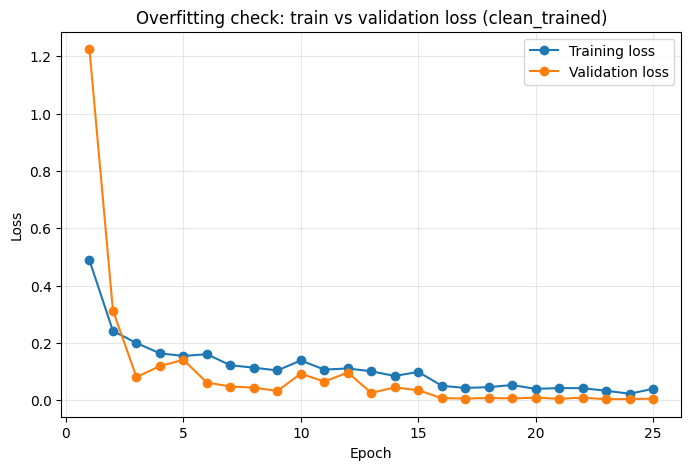

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final/accuracy_curves/overfitting_train_val_loss_clean_trained_runs_1_to_9.png


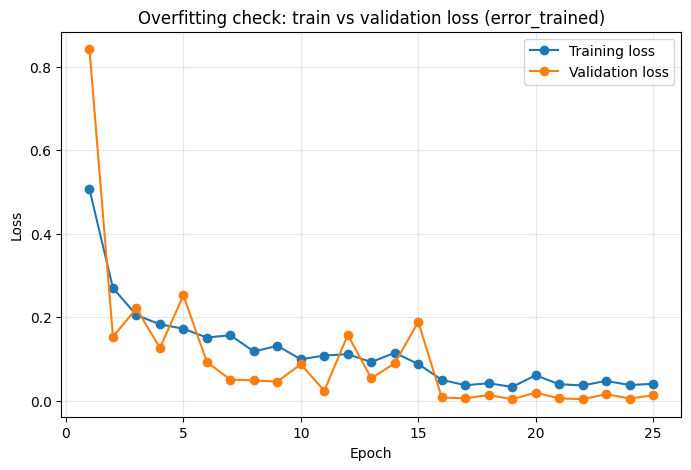

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final/accuracy_curves/overfitting_train_val_loss_error_trained_runs_1_to_9.png


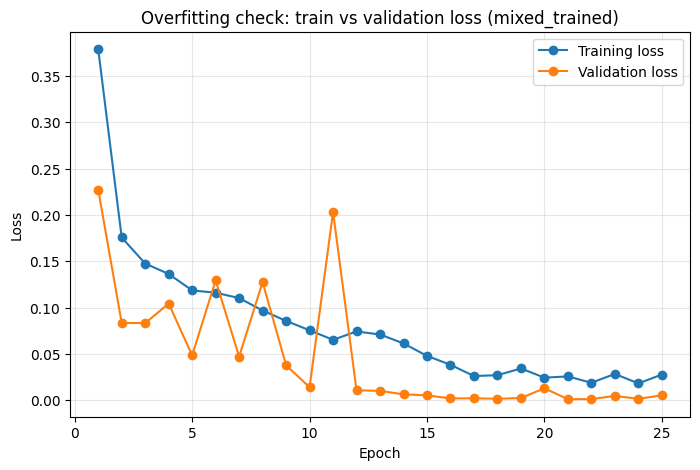

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final/accuracy_curves/overfitting_train_val_loss_mixed_trained_runs_1_to_9.png


In [ ]:
# Plot average training and validation loss curves

loss_summary = (
    history_df
    .groupby(["train_condition", epoch_col])
    .agg(
        mean_train_loss=(train_loss_col, "mean"),
        mean_val_loss=(val_loss_col, "mean")
    )
    .reset_index()
)

for condition in expected_conditions:
    subset = loss_summary[loss_summary["train_condition"] == condition]

    plt.figure(figsize=(8, 5))
    plt.plot(subset[epoch_col], subset["mean_train_loss"], marker="o", label="Training loss")
    plt.plot(subset[epoch_col], subset["mean_val_loss"], marker="o", label="Validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Overfitting check: train vs validation loss ({condition})")
    plt.grid(alpha=0.3)
    plt.legend()

    fig_path = FIGURES_DIR / "accuracy_curves" / f"overfitting_train_val_loss_{condition}_runs_1_to_9.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

In [ ]:
# Compare validation accuracy with final test accuracy

summary_path = RESULTS_DIR / "test_results" / "all_experiments_summary_runs_1_to_9.csv"
results_df = pd.read_csv(summary_path)
results_df["test_accuracy_percent"] = results_df["test_accuracy"] * 100

val_mean_df = (
    gap_df
    .groupby(["train_condition", "run_id"])
    .agg(final_val_accuracy_percent=("final_val_accuracy_percent", "mean"))
    .reset_index()
)

test_mean_df = (
    results_df
    .groupby(["train_condition", "run_id"])
    .agg(mean_test_accuracy_percent=("test_accuracy_percent", "mean"))
    .reset_index()
)

val_test_compare_df = pd.merge(
    val_mean_df,
    test_mean_df,
    on=["train_condition", "run_id"],
    how="inner"
)

val_test_compare_df["val_test_gap_percent"] = (
    val_test_compare_df["final_val_accuracy_percent"] -
    val_test_compare_df["mean_test_accuracy_percent"]
)

val_test_compare_df = val_test_compare_df.round(4)

val_test_path = RESULTS_DIR / "statistics" / "overfitting_validation_test_gap_runs_1_to_9.csv"
val_test_compare_df.to_csv(val_test_path, index=False)

print("Saved validation-test gap table:")
print(val_test_path)

display(val_test_compare_df)

print("\nAverage validation-test gap by condition:")
display(
    val_test_compare_df
    .groupby("train_condition")["val_test_gap_percent"]
    .agg(["mean", "min", "max"])
    .round(4)
)

Saved validation-test gap table:
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final/statistics/overfitting_validation_test_gap_runs_1_to_9.csv


,train_condition,run_id,final_val_accuracy_percent,mean_test_accuracy_percent,val_test_gap_percent
0,clean_trained,1,100.0000,99.5556,0.4444
1,clean_trained,2,100.0000,99.9444,0.0556
2,clean_trained,3,99.8333,99.7778,0.0555
3,clean_trained,4,99.6667,100.0000,-0.3333
4,clean_trained,5,100.0000,100.0000,0.0000
5,clean_trained,6,100.0000,100.0000,0.0000
6,clean_trained,7,100.0000,100.0000,0.0000
7,clean_trained,8,100.0000,100.0000,0.0000
8,clean_trained,9,100.0000,100.0000,0.0000
9,error_trained,1,96.8333,100.0000,-3.1667



Average validation-test gap by condition:


,mean,min,max
train_condition,,,
clean_trained,0.0247,-0.3333,0.4444
error_trained,-0.4012,-3.1667,0.2778
mixed_trained,-0.0864,-1.6666,0.3333


In [ ]:
# Data leakage check using file paths

manifest_path = METADATA_DIR / "dataset_manifest_v2.csv"
manifest_df = pd.read_csv(manifest_path)

train_roles = ["train_clean_condition", "train_error_condition"]
eval_roles = ["validation", "test_clean", "test_error", "test_error_double"]

train_df_leak = manifest_df[manifest_df["role"].isin(train_roles)].copy()
eval_df_leak = manifest_df[manifest_df["role"].isin(eval_roles)].copy()

train_paths = set(train_df_leak["path"].astype(str))
eval_paths = set(eval_df_leak["path"].astype(str))

path_overlap = train_paths.intersection(eval_paths)

print("Train files:", len(train_paths))
print("Evaluation files:", len(eval_paths))
print("Full path overlap:", len(path_overlap))

if len(path_overlap) > 0:
    print("Overlapping paths found:")
    for p in list(path_overlap)[:20]:
        print(p)
else:
    print("No full-path overlap found between training and evaluation files.")

Train files: 1182
Evaluation files: 2400
Full path overlap: 0
No full-path overlap found between training and evaluation files.


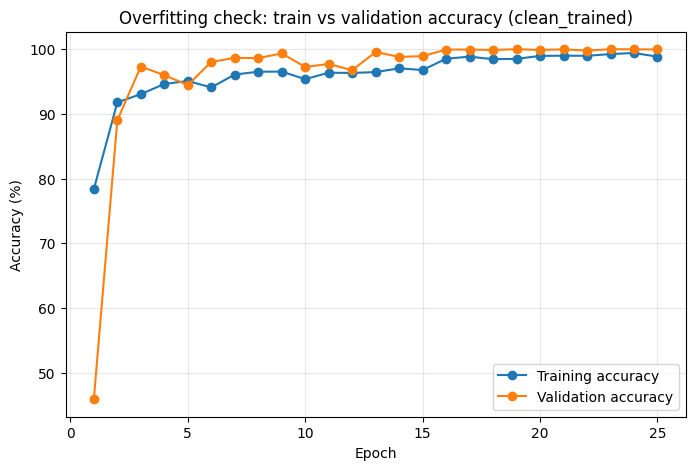

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final/accuracy_curves/overfitting_train_val_accuracy_clean_trained_runs_1_to_9.png


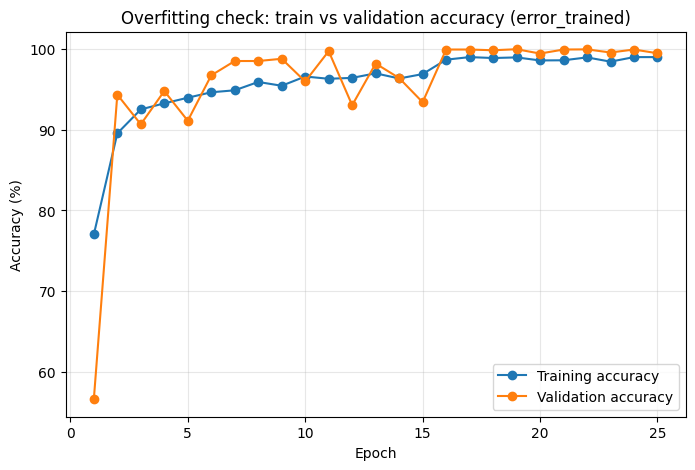

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final/accuracy_curves/overfitting_train_val_accuracy_error_trained_runs_1_to_9.png


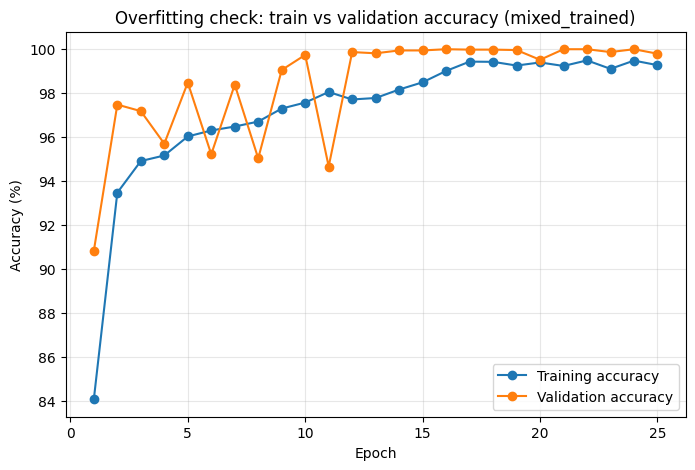

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final/accuracy_curves/overfitting_train_val_accuracy_mixed_trained_runs_1_to_9.png


In [ ]:
# Plot average training and validation accuracy curves

curve_summary = (
    history_df
    .groupby(["train_condition", epoch_col])
    .agg(
        mean_train_acc=(train_acc_col, "mean"),
        mean_val_acc=(val_acc_col, "mean")
    )
    .reset_index()
)

for condition in expected_conditions:
    subset = curve_summary[curve_summary["train_condition"] == condition]

    plt.figure(figsize=(8, 5))
    plt.plot(subset[epoch_col], subset["mean_train_acc"] * 100, marker="o", label="Training accuracy")
    plt.plot(subset[epoch_col], subset["mean_val_acc"] * 100, marker="o", label="Validation accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Overfitting check: train vs validation accuracy ({condition})")
    plt.grid(alpha=0.3)
    plt.legend()

    fig_path = FIGURES_DIR / "accuracy_curves" / f"overfitting_train_val_accuracy_{condition}_runs_1_to_9.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

In [ ]:
# ============================================================
# FINAL CELL — Save Notebook 02 completion status
# ============================================================

notebook2_status = {
    "notebook": "02_aps_xyz_normals_experiments",
    "purpose": (
        "Train and evaluate the original PointNet++ XYZ + normals "
        "baseline on APS clean, error and mixed training conditions."
    ),
    "input_type": "XYZ + normals",
    "use_normals": True,
    "n_points": 1000,
    "training_conditions": [
        "clean_trained",
        "error_trained",
        "mixed_trained"
    ],
    "n_runs": 9,
    "full_epochs": 25,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "test_sets": [
        "APS-clean",
        "APS-error",
        "APS-error-double"
    ],
    "status": "completed"
}

status_path = RESULTS_DIR / "02_aps_xyz_normals_experiments_status.json"

with open(status_path, "w") as f:
    json.dump(notebook2_status, f, indent=4)

print("Notebook 02 completed.")
print("Saved status file:")
print(status_path)

notebook2_status